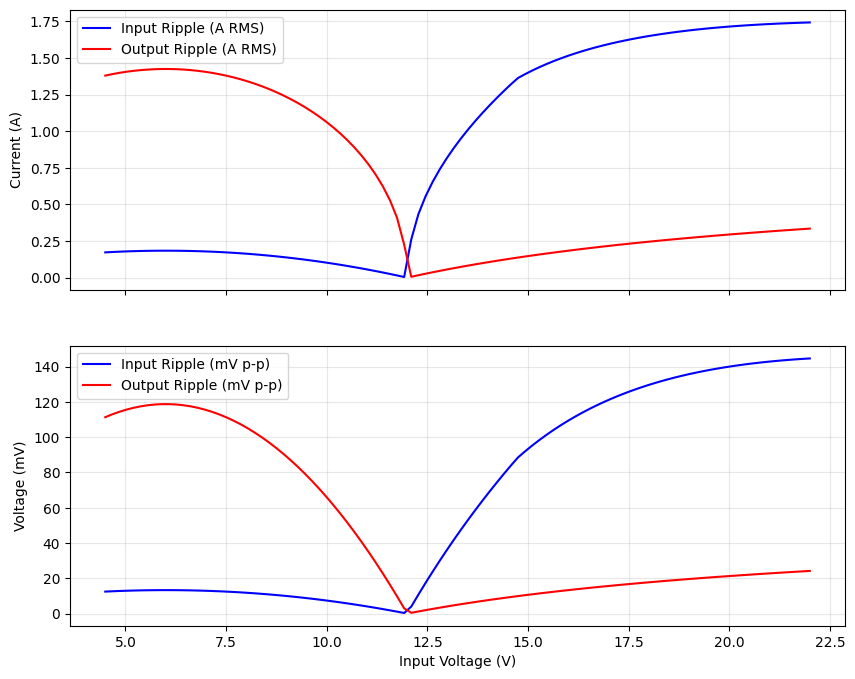

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
L = 47e-6          # Inductor Value
f_sw = 100e3       # Switching Frequency
v_out_target = 12.0
i_in_limit = 3.0   # Input current limit from source
i_out_max = 3.5    # Maximum load demand
est_eff = 0.95     # Estimated efficiency for power limit math

# Capacitor Assumptions (Effective values after DC Bias derating)
c_out = 60e-6      # e.g., 3x 47uF, roughly 20uF each at 12V
c_in = 60e-6       # e.g., 2x 47uF

v_in_range = np.linspace(4.5, 22.0, 100)
data = []

for v_in in v_in_range:
    # 1. Power Limit Logic
    p_in_max = v_in * i_in_limit
    p_out_demand = v_out_target * i_out_max
    p_out = min(p_out_demand, p_in_max * est_eff)
    i_out = p_out / v_out_target
    
    # 2. Ripple Calculations
    if v_in < v_out_target: # Boost Mode
        d = 1 - (v_in / v_out_target)
        delta_il = (v_in * d) / (L * f_sw)
        i_out_ripple_rms = i_out * np.sqrt(d / (1 - d))
        v_out_ripple_pp = (i_out * d) / (f_sw * c_out)
        i_in_ripple_rms = delta_il / np.sqrt(12)
        v_in_ripple_pp = delta_il / (8 * f_sw * c_in)
    else: # Buck Mode
        d = v_out_target / v_in
        delta_il = (v_in - v_out_target) * d / (L * f_sw)
        i_out_ripple_rms = delta_il / np.sqrt(12)
        v_out_ripple_pp = delta_il / (8 * f_sw * c_out)
        i_in_ripple_rms = i_out * np.sqrt(d * (1 - d))
        v_in_ripple_pp = (i_out * d * (1 - d)) / (f_sw * c_in)

    data.append({
        'Vin': v_in, 'Iout': i_out, 'Iin_Ripple_RMS': i_in_ripple_rms,
        'Iout_Ripple_RMS': i_out_ripple_rms, 'Vin_Ripple_mV': v_in_ripple_pp*1000,
        'Vout_Ripple_mV': v_out_ripple_pp*1000
    })

df = pd.DataFrame(data)

# --- PLOTTING ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax1.plot(df['Vin'], df['Iin_Ripple_RMS'], label='Input Ripple (A RMS)', color='blue')
ax1.plot(df['Vin'], df['Iout_Ripple_RMS'], label='Output Ripple (A RMS)', color='red')
ax1.set_ylabel('Current (A)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(df['Vin'], df['Vin_Ripple_mV'], label='Input Ripple (mV p-p)', color='blue')
ax2.plot(df['Vin'], df['Vout_Ripple_mV'], label='Output Ripple (mV p-p)', color='red')
ax2.set_ylabel('Voltage (mV)')
ax2.set_xlabel('Input Voltage (V)')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.show()